# APEBench Data Visualization

This notebook visualizes data generated by the APEBench integration module for FlowPDE.

**Contents:**
1. Load cached Burgers 1D data
2. Visualize initial conditions and final states
3. Animate trajectories over time
4. Visualize Poisson 2D source-solution pairs
5. Statistical analysis of the datasets

In [4]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import json
from pathlib import Path

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Burgers 1D Data

Load the cached Burgers equation dataset generated by APEBench.

In [5]:
# Load Burgers 1D cached data
burgers_path = Path('../.cache/apebench/burgers_1d/res160_nu0.0003_n50_t50_s0')
burgers_data = torch.load(burgers_path / 'train.pt', weights_only=False)

# Load metadata
with open(burgers_path / 'metadata.json', 'r') as f:
    burgers_meta = json.load(f)

print("Burgers 1D Dataset")
print("=" * 50)
print(f"Data keys: {list(burgers_data.keys())}")
print(f"\nShapes:")
print(f"  Initial conditions: {burgers_data['initial'].shape}")
print(f"  Final states:       {burgers_data['final'].shape}")
print(f"  Trajectories:       {burgers_data['trajectory'].shape}")
print(f"  Time points:        {burgers_data['time'].shape}")
print(f"\nPhysics parameters:")
print(f"  Viscosity (ν):      {burgers_data['viscosity']}")
print(f"\nGeneration config:")
print(f"  Resolution:         {burgers_meta['params']['num_points']}")
print(f"  Samples:            {burgers_meta['params']['num_train_samples']}")

Burgers 1D Dataset
Data keys: ['initial', 'final', 'trajectory', 'time', 'viscosity', 'stats', 'config']

Shapes:
  Initial conditions: torch.Size([50, 1, 160])
  Final states:       torch.Size([50, 1, 160])
  Trajectories:       torch.Size([50, 50, 1, 160])
  Time points:        torch.Size([50])

Physics parameters:
  Viscosity (ν):      0.0003

Generation config:
  Resolution:         160
  Samples:            50


## 2. Visualize Initial and Final States

Compare initial conditions with their corresponding final states after time evolution.

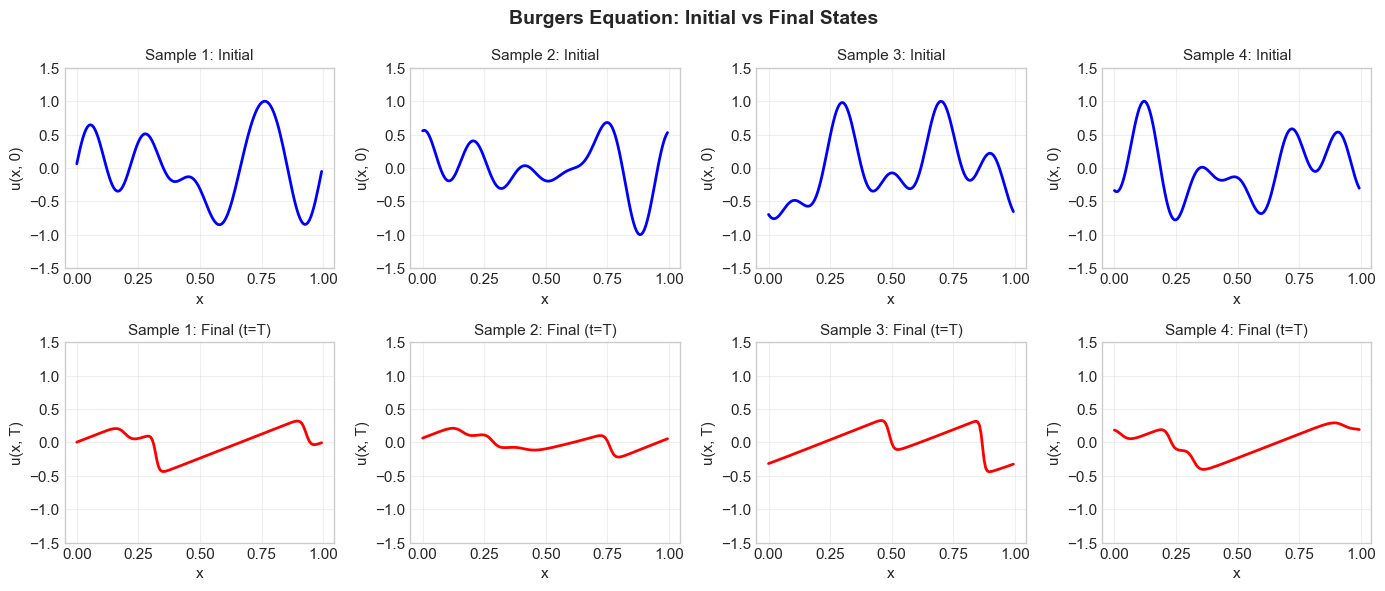

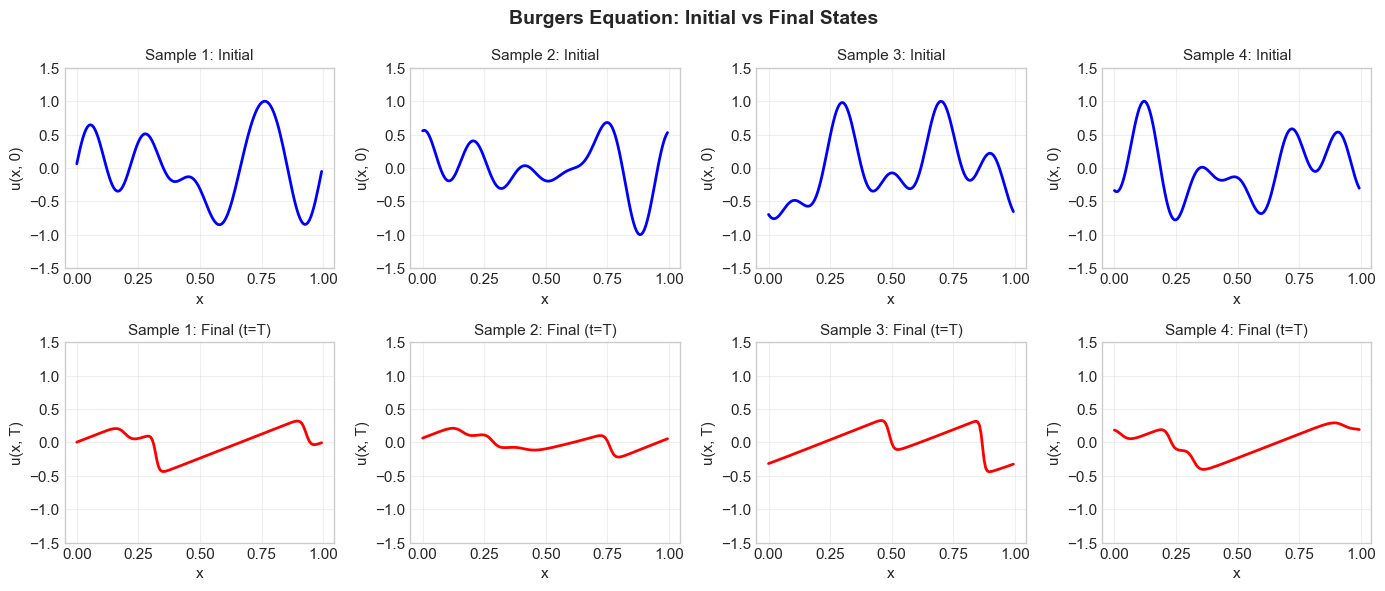

In [6]:
# Extract data
initial = burgers_data['initial'].numpy()  # (N, 1, 160)
final = burgers_data['final'].numpy()      # (N, 1, 160)
n_samples = initial.shape[0]
resolution = initial.shape[-1]

# Spatial grid (assuming domain [0, 1])
x = np.linspace(0, 1, resolution, endpoint=False)

# Plot several samples
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(14, 6))

for i in range(n_show):
    # Initial condition
    axes[0, i].plot(x, initial[i, 0, :], 'b-', linewidth=2)
    axes[0, i].set_title(f'Sample {i+1}: Initial', fontsize=11)
    axes[0, i].set_xlabel('x')
    axes[0, i].set_ylabel('u(x, 0)')
    axes[0, i].set_ylim(-1.5, 1.5)
    axes[0, i].grid(True, alpha=0.3)
    
    # Final state
    axes[1, i].plot(x, final[i, 0, :], 'r-', linewidth=2)
    axes[1, i].set_title(f'Sample {i+1}: Final (t=T)', fontsize=11)
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel('u(x, T)')
    axes[1, i].set_ylim(-1.5, 1.5)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Burgers Equation: Initial vs Final States', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Spatio-Temporal Evolution (Heatmaps)

Visualize the full trajectory as a space-time heatmap showing how the solution evolves.

/var/folders/ll/tq8ksk3s1bl60rb4p7dr31f40000gn/T/ipykernel_40683/1249703399.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


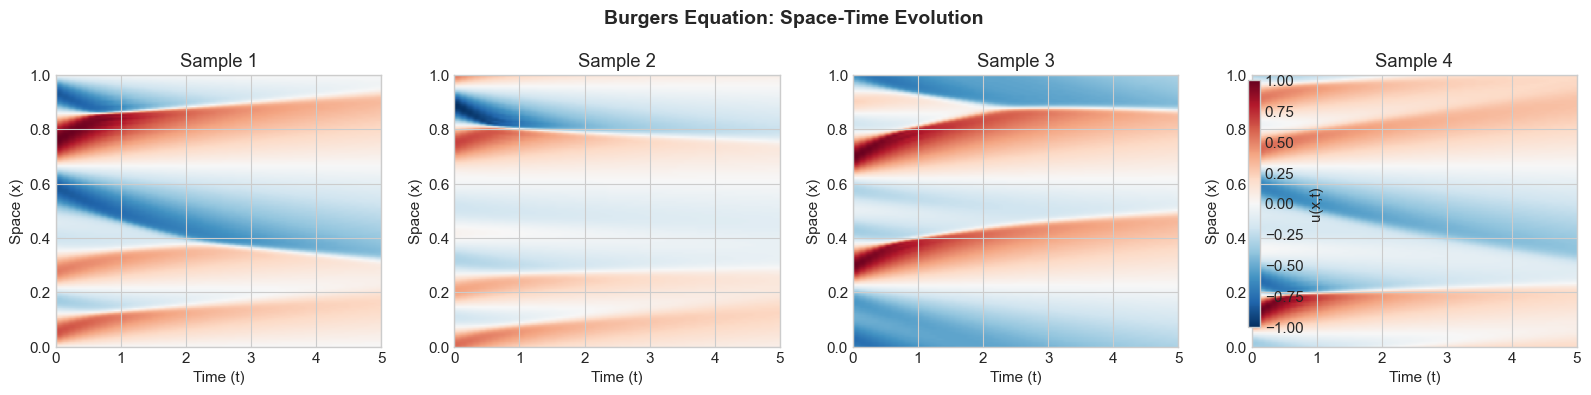

In [7]:
# Get trajectory data
trajectory = burgers_data['trajectory'].numpy()  # (N, T, 1, 160)
time = burgers_data['time'].numpy()              # (T,)

# Include initial condition in full trajectory for visualization
full_traj = np.concatenate([initial[:, np.newaxis, :, :], trajectory], axis=1)  # (N, T+1, 1, 160)
full_time = np.concatenate([[0], time])

# Plot space-time heatmaps for several samples
n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(16, 4))

for i in range(n_show):
    # Extract trajectory for sample i: (T+1, 160)
    traj_i = full_traj[i, :, 0, :]
    
    im = axes[i].imshow(
        traj_i.T,
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        vmin=-1, vmax=1,
        extent=[0, full_time[-1], 0, 1]
    )
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('Space (x)')
    axes[i].set_title(f'Sample {i+1}')

plt.suptitle('Burgers Equation: Space-Time Evolution', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=axes, label='u(x,t)', shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Animation of Time Evolution

Create an animation showing the solution evolving over time.

In [8]:
# Create animation for a single sample
sample_idx = 0
traj = full_traj[sample_idx, :, 0, :]  # (T+1, 160)

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot(x, traj[0], 'b-', linewidth=2)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x, t)', fontsize=12)
ax.grid(True, alpha=0.3)
title = ax.set_title(f'Burgers Equation Evolution (t = 0.00)', fontsize=14)

def animate(frame):
    line.set_ydata(traj[frame])
    title.set_text(f'Burgers Equation Evolution (t = {full_time[frame]:.2f})')
    return line, title

anim = FuncAnimation(fig, animate, frames=len(full_time), interval=100, blit=True)
plt.close()

# Display animation
HTML(anim.to_jshtml())

## 5. Poisson 2D Visualization

Load and visualize the 2D Poisson equation source-solution pairs.

In [ ]:
# Load Poisson 2D data
poisson_path = Path('../.cache/apebench/poisson_2d/res64_n50_t1_s0_L10.0')
poisson_data = torch.load(poisson_path / 'train.pt', weights_only=False)

print("Poisson 2D Dataset")
print("=" * 50)
print(f"Data keys: {list(poisson_data.keys())}")
print(f"\nShapes:")
print(f"  Source terms (f):   {poisson_data['source'].shape}")
print(f"  Solutions (u):      {poisson_data['solution'].shape}")

Poisson 2D Dataset
Data keys: ['source', 'solution', 'domain_extent', 'order', 'stats', 'config']

Shapes:
  Source terms (f):   torch.Size([50, 1, 64, 64])
  Solutions (u):      torch.Size([50, 1, 64, 64])

PDE: -∇²u = f (periodic boundary conditions)


/var/folders/ll/tq8ksk3s1bl60rb4p7dr31f40000gn/T/ipykernel_40683/2728119434.py:23: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sarperyurtseven/Desktop/sarper/.envs/flowpde/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


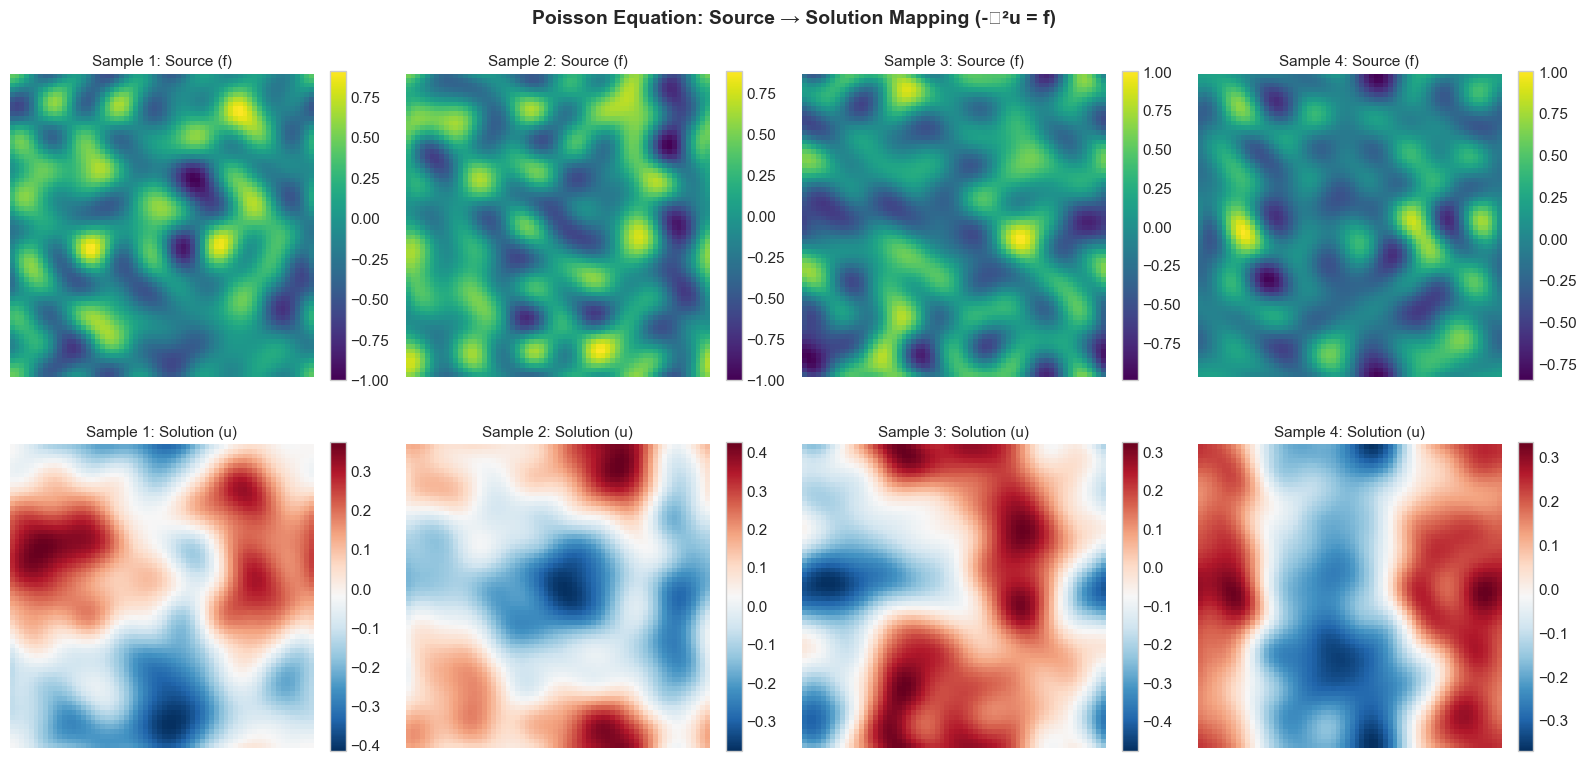

In [ ]:
# Extract source and solution
source = poisson_data['source'].numpy()      # (N, 1, 64, 64)
solution = poisson_data['solution'].numpy()  # (N, 1, 64, 64)

# Plot several source-solution pairs
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(16, 8))

for i in range(n_show):
    # Source term (f)
    im1 = axes[0, i].imshow(source[i, 0], cmap='viridis', origin='lower')
    axes[0, i].set_title(f'Sample {i+1}: Source (f)', fontsize=11)
    axes[0, i].axis('off')
    plt.colorbar(im1, ax=axes[0, i], fraction=0.046)
    
    # Solution (u)
    im2 = axes[1, i].imshow(solution[i, 0], cmap='RdBu_r', origin='lower')
    axes[1, i].set_title(f'Sample {i+1}: Solution (u)', fontsize=11)
    axes[1, i].axis('off')
    plt.colorbar(im2, ax=axes[1, i], fraction=0.046)

plt.suptitle('Poisson Equation: Source → Solution Mapping ($f = -\\nabla^2 u$)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Statistical Analysis

Analyze the distribution of values across the datasets.

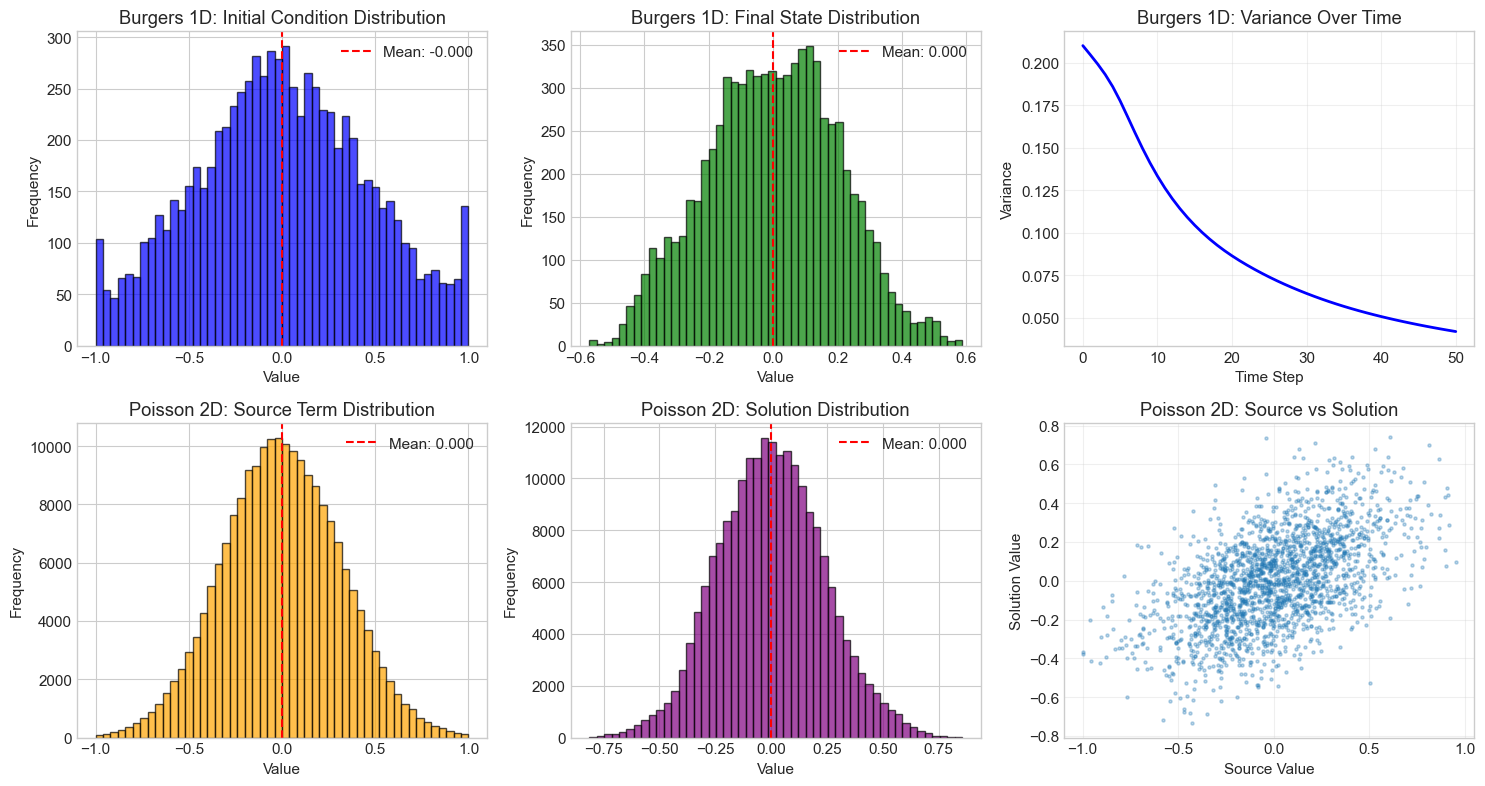


DATASET SUMMARY STATISTICS

Burgers 1D:
  Initial shape: (50, 1, 160)
  Final shape:   (50, 1, 160)
  Initial - Mean: -0.0000, Std: 0.4583
  Final   - Mean: 0.0000, Std: 0.2048
  Range: [-1.0000, 1.0000]

Poisson 2D:
  Source shape: (50, 1, 64, 64)
  Solution shape: (50, 1, 64, 64)
  Source   - Mean: 0.0000, Std: 0.3159
  Solution - Mean: 0.0000, Std: 0.2370


In [15]:
# Statistical analysis of the datasets
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Burgers 1D statistics (using 'initial' and 'final' numpy arrays from earlier cells)
burgers_initial_flat = initial.flatten()
burgers_final_flat = final.flatten()

axes[0, 0].hist(burgers_initial_flat, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Burgers 1D: Initial Condition Distribution')
axes[0, 0].axvline(burgers_initial_flat.mean(), color='red', linestyle='--', label=f'Mean: {burgers_initial_flat.mean():.3f}')
axes[0, 0].legend()

axes[0, 1].hist(burgers_final_flat, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Burgers 1D: Final State Distribution')
axes[0, 1].axvline(burgers_final_flat.mean(), color='red', linestyle='--', label=f'Mean: {burgers_final_flat.mean():.3f}')
axes[0, 1].legend()

# Variance over time for Burgers (using full_traj from earlier cell)
full_traj_tensor = torch.from_numpy(full_traj)  # Convert to tensor for variance calculation
burgers_variance = full_traj_tensor.var(dim=(0, 2, 3)).numpy()  # Variance across samples, channels, space
axes[0, 2].plot(burgers_variance, 'b-', linewidth=2)
axes[0, 2].set_xlabel('Time Step')
axes[0, 2].set_ylabel('Variance')
axes[0, 2].set_title('Burgers 1D: Variance Over Time')
axes[0, 2].grid(True, alpha=0.3)

# Poisson 2D statistics (using 'source' and 'solution' numpy arrays from earlier cells)
source_flat = source.flatten()
solution_flat = solution.flatten()

axes[1, 0].hist(source_flat, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Poisson 2D: Source Term Distribution')
axes[1, 0].axvline(source_flat.mean(), color='red', linestyle='--', label=f'Mean: {source_flat.mean():.3f}')
axes[1, 0].legend()

axes[1, 1].hist(solution_flat, bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Poisson 2D: Solution Distribution')
axes[1, 1].axvline(solution_flat.mean(), color='red', linestyle='--', label=f'Mean: {solution_flat.mean():.3f}')
axes[1, 1].legend()

# Source vs Solution correlation
axes[1, 2].scatter(source_flat[::100], solution_flat[::100], alpha=0.3, s=5)
axes[1, 2].set_xlabel('Source Value')
axes[1, 2].set_ylabel('Solution Value')
axes[1, 2].set_title('Poisson 2D: Source vs Solution')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("DATASET SUMMARY STATISTICS")
print("="*60)
print(f"\nBurgers 1D:")
print(f"  Initial shape: {initial.shape}")
print(f"  Final shape:   {final.shape}")
print(f"  Initial - Mean: {burgers_initial_flat.mean():.4f}, Std: {burgers_initial_flat.std():.4f}")
print(f"  Final   - Mean: {burgers_final_flat.mean():.4f}, Std: {burgers_final_flat.std():.4f}")
print(f"  Range: [{initial.min():.4f}, {initial.max():.4f}]")

print(f"\nPoisson 2D:")
print(f"  Source shape: {source.shape}")
print(f"  Solution shape: {solution.shape}")
print(f"  Source   - Mean: {source_flat.mean():.4f}, Std: {source_flat.std():.4f}")
print(f"  Solution - Mean: {solution_flat.mean():.4f}, Std: {solution_flat.std():.4f}")

## 7. Multiple Samples Comparison

Compare multiple samples side by side to see the variety in the generated data.

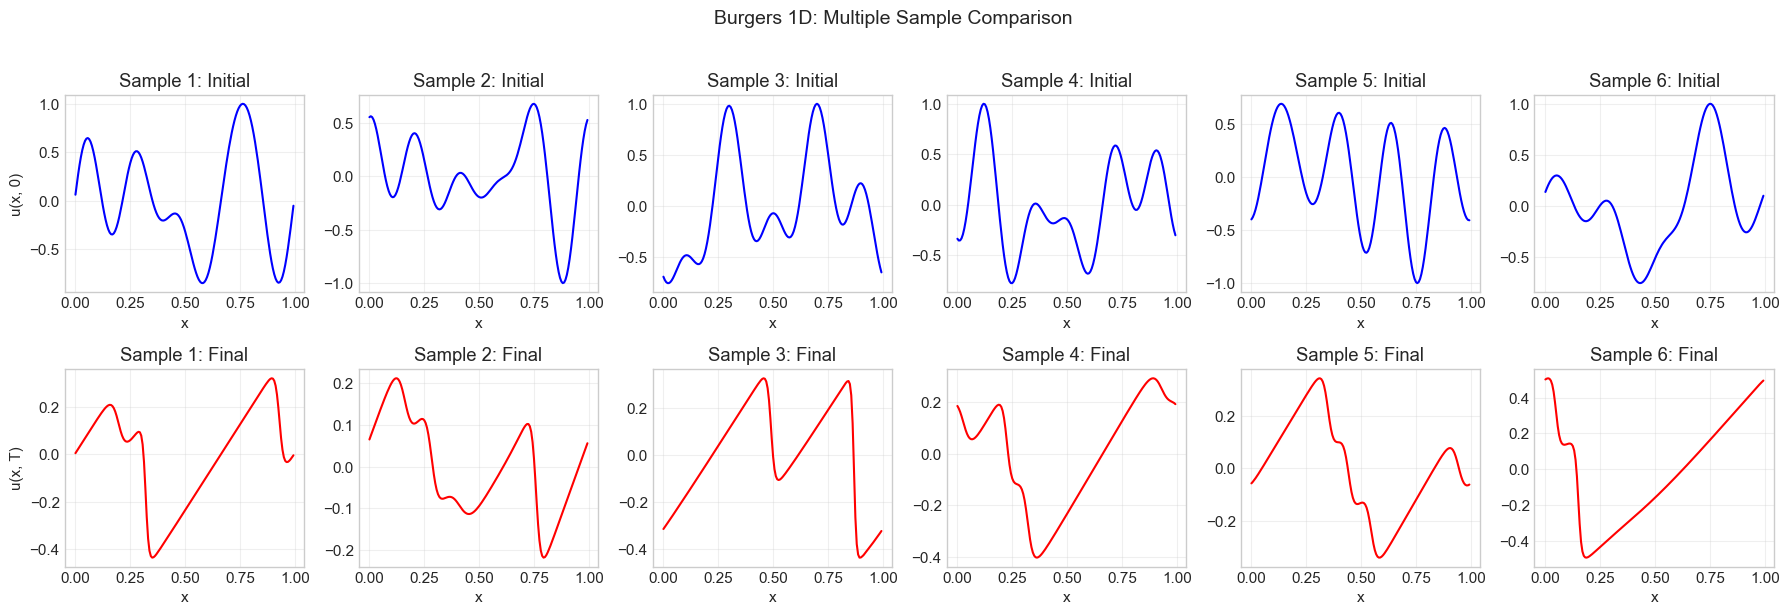

In [16]:
# Compare multiple Burgers samples
n_compare = 6
fig, axes = plt.subplots(2, n_compare, figsize=(18, 6))

for i in range(n_compare):
    # Initial conditions (top row) - using 'initial' numpy array
    axes[0, i].plot(x, initial[i, 0, :], 'b-', linewidth=1.5)
    axes[0, i].set_title(f'Sample {i+1}: Initial')
    axes[0, i].set_xlabel('x')
    if i == 0:
        axes[0, i].set_ylabel('u(x, 0)')
    axes[0, i].grid(True, alpha=0.3)
    
    # Final states (bottom row) - using 'final' numpy array
    axes[1, i].plot(x, final[i, 0, :], 'r-', linewidth=1.5)
    axes[1, i].set_title(f'Sample {i+1}: Final')
    axes[1, i].set_xlabel('x')
    if i == 0:
        axes[1, i].set_ylabel('u(x, T)')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Burgers 1D: Multiple Sample Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

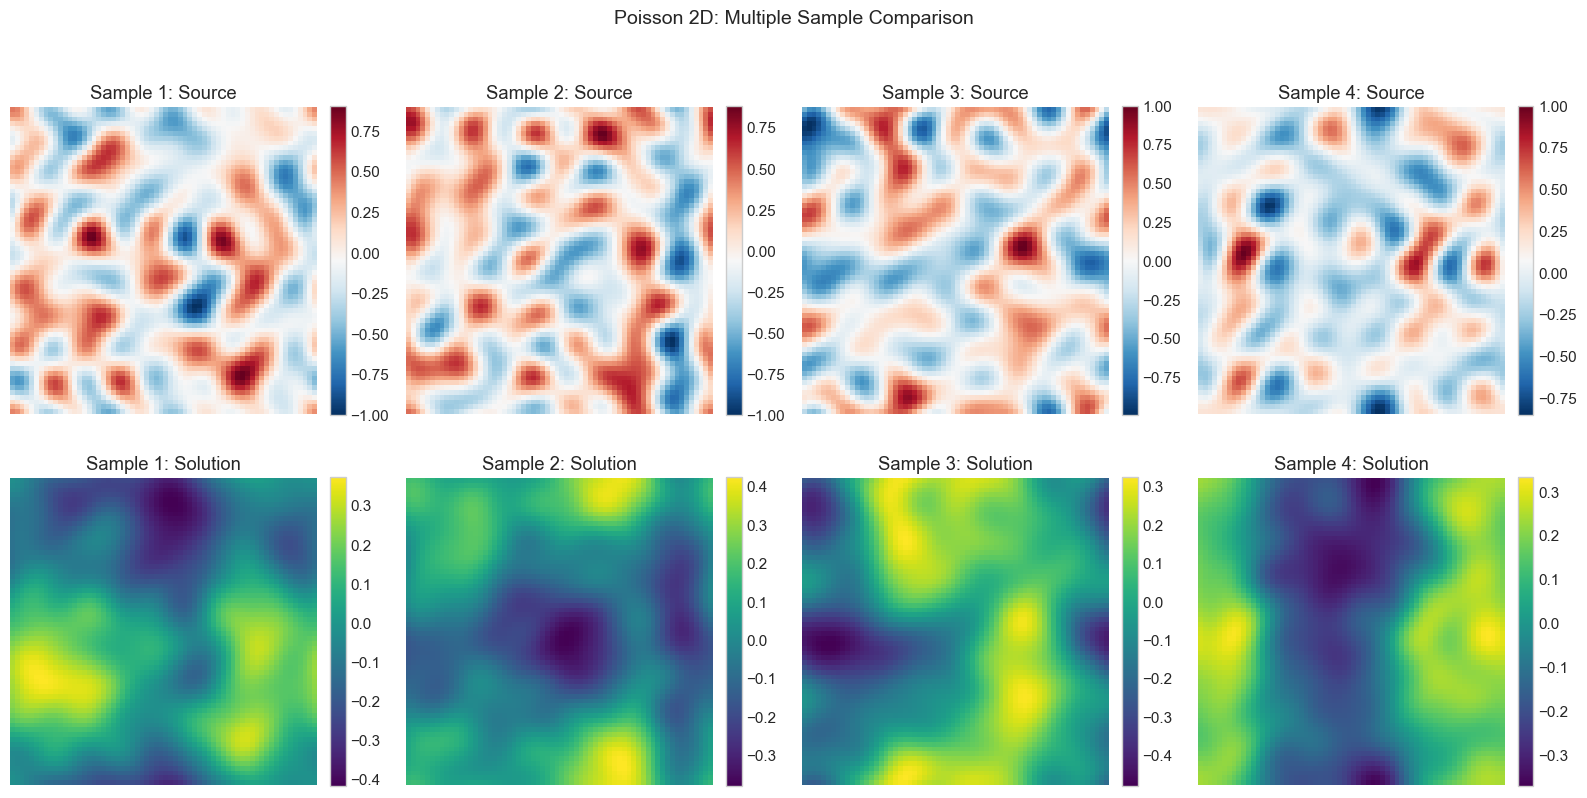

In [17]:
# Compare multiple Poisson samples
n_compare = 4
fig, axes = plt.subplots(2, n_compare, figsize=(16, 8))

for i in range(n_compare):
    # Source terms (top row) - using 'source' numpy array
    im1 = axes[0, i].imshow(source[i, 0], cmap='RdBu_r', aspect='equal')
    axes[0, i].set_title(f'Sample {i+1}: Source')
    axes[0, i].axis('off')
    plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)
    
    # Solutions (bottom row) - using 'solution' numpy array
    im2 = axes[1, i].imshow(solution[i, 0], cmap='viridis', aspect='equal')
    axes[1, i].set_title(f'Sample {i+1}: Solution')
    axes[1, i].axis('off')
    plt.colorbar(im2, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.suptitle('Poisson 2D: Multiple Sample Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Energy/Norm Evolution

Track how the solution norm evolves over time for Burgers equation.

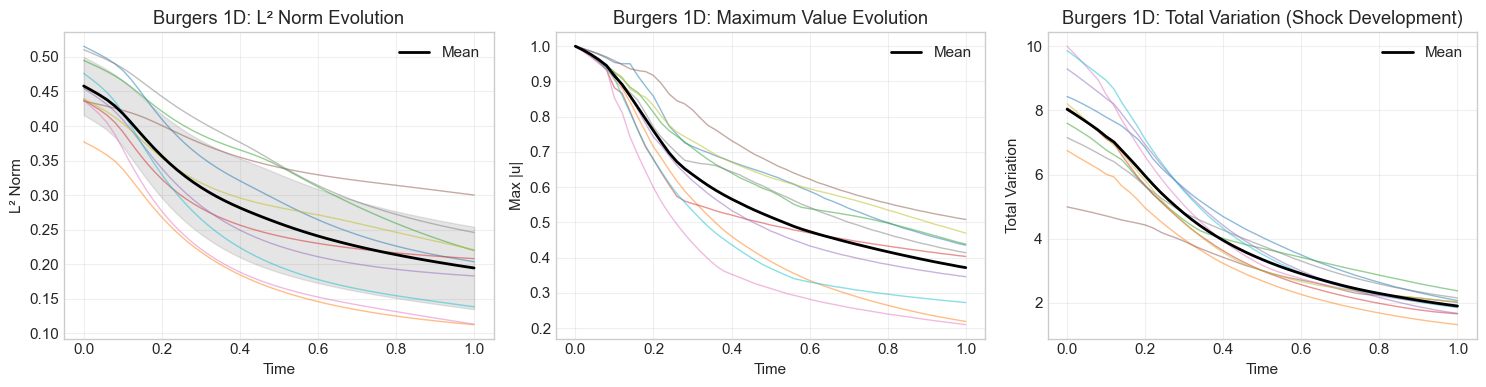


Observations:
- L² norm typically decreases due to viscous dissipation
- Maximum value evolution shows shock formation/dissipation
- Total variation increase indicates shock steepening


In [18]:
# Compute L2 norm over time for each sample
# Using full_traj numpy array from earlier cells: (N, T+1, 1, 160)
n_samples = min(10, full_traj.shape[0])
n_timesteps = full_traj.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Convert to tensor for easier computation
full_traj_tensor = torch.from_numpy(full_traj[:n_samples])  # (n_samples, T+1, 1, 160)

# L2 norm evolution
l2_norms = torch.sqrt((full_traj_tensor[:, :, 0, :] ** 2).mean(dim=-1))  # (samples, time)
time_axis = np.linspace(0, 1, n_timesteps)

for i in range(n_samples):
    axes[0].plot(time_axis, l2_norms[i].numpy(), alpha=0.5, linewidth=1)
axes[0].plot(time_axis, l2_norms.mean(dim=0).numpy(), 'k-', linewidth=2, label='Mean')
axes[0].fill_between(time_axis, 
                      (l2_norms.mean(dim=0) - l2_norms.std(dim=0)).numpy(),
                      (l2_norms.mean(dim=0) + l2_norms.std(dim=0)).numpy(),
                      alpha=0.2, color='gray')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('L² Norm')
axes[0].set_title('Burgers 1D: L² Norm Evolution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Maximum value evolution
max_vals = full_traj_tensor[:, :, 0, :].abs().max(dim=-1)[0]  # (samples, time)
for i in range(n_samples):
    axes[1].plot(time_axis, max_vals[i].numpy(), alpha=0.5, linewidth=1)
axes[1].plot(time_axis, max_vals.mean(dim=0).numpy(), 'k-', linewidth=2, label='Mean')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Max |u|')
axes[1].set_title('Burgers 1D: Maximum Value Evolution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Total variation (measure of shock sharpness)
total_variation = torch.abs(torch.diff(full_traj_tensor[:, :, 0, :], dim=-1)).sum(dim=-1)
for i in range(n_samples):
    axes[2].plot(time_axis, total_variation[i].numpy(), alpha=0.5, linewidth=1)
axes[2].plot(time_axis, total_variation.mean(dim=0).numpy(), 'k-', linewidth=2, label='Mean')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Total Variation')
axes[2].set_title('Burgers 1D: Total Variation (Shock Development)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- L² norm typically decreases due to viscous dissipation")
print("- Maximum value evolution shows shock formation/dissipation")
print("- Total variation increase indicates shock steepening")